# RaksaDana - BBRI.JK Return-Based LSTM Modelling & Evaluation

Target utama notebook ini adalah `Next_Log_Return`, bukan raw scaled `Close`. Harga tetap dievaluasi dengan rekonstruksi `current_close * exp(predicted_return)`, sehingga model tidak dipaksa extrapolate level harga saat test melewati range train.


## Setup


In [17]:
import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import ks_2samp
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout, LayerNormalization
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.regularizers import l2
except Exception as exc:
    tf = None
    TF_IMPORT_ERROR = exc
else:
    TF_IMPORT_ERROR = None

warnings.filterwarnings('ignore')
%matplotlib inline

TICKER = 'BBRI.JK'
SAFE_TICKER = TICKER.replace('.', '_')
SEEDS = [42, 123, 7]
WINDOW_SIZE = 60
TEST_SIZE = 0.20
VAL_SIZE = 0.15

cwd = Path.cwd()
ROOT = cwd.parent if cwd.name.lower() == 'notebook' else cwd
PROCESSED_DIR = ROOT / 'data' / 'processed'
MODEL_DIR = ROOT / 'models'
REPORT_DIR = ROOT / 'reports'
RETURN_PLOT_DIR = PROCESSED_DIR / 'return_model' / SAFE_TICKER
RETURN_REPORT_DIR = REPORT_DIR / 'return_model' / SAFE_TICKER
RETURN_MODEL_DIR = MODEL_DIR / 'return_model'
for _dir in [MODEL_DIR, REPORT_DIR, RETURN_PLOT_DIR, RETURN_REPORT_DIR, RETURN_MODEL_DIR]:
    _dir.mkdir(parents=True, exist_ok=True)

ACTUAL_COLOR = '#1565C0'
LSTM_COLOR = '#D32F2F'
RIDGE_COLOR = '#2E7D32'
MA5_COLOR = '#F57C00'
NAIVE_COLOR = '#6D6D6D'
MODEL_COLORS = {
    'Actual': ACTUAL_COLOR,
    'Naive': NAIVE_COLOR,
    'MA5': MA5_COLOR,
    'Ridge': RIDGE_COLOR,
    'LSTM': LSTM_COLOR,
}

print(f'Ticker        : {TICKER}')
print(f'ROOT          : {ROOT}')
print(f'PLOT DIR      : {RETURN_PLOT_DIR}')
print(f'REPORT DIR    : {RETURN_REPORT_DIR}')
print(f'TensorFlow    : {tf.__version__ if tf is not None else "not available"}')
if TF_IMPORT_ERROR is not None:
    print(f'TensorFlow import error: {TF_IMPORT_ERROR}')


Ticker        : BBRI.JK
ROOT          : c:\Users\akbar\VSCode Project\RaksaDana
TensorFlow    : 2.21.0


## Metric Display Helper
Cell ini cuma helper supaya tabel evaluasi muncul jelas di notebook.


In [18]:
METRIC_FORMAT = {
    'Return_MAE': '{:.5f}',
    'Return_RMSE': '{:.5f}',
    'Price_MAE': '{:,.2f}',
    'Price_RMSE': '{:,.2f}',
    'Price_MAPE': '{:.3f}%',
    'Price_R2': '{:.4f}',
    'Direction_Accuracy': '{:.2f}%',
}

METRIC_COLUMNS = [
    'Ticker', 'Split', 'Model',
    'Return_MAE', 'Return_RMSE',
    'Price_MAE', 'Price_RMSE', 'Price_MAPE', 'Price_R2',
    'Direction_Accuracy',
]

def show_metrics(title, table):
    print('\n' + '=' * 90)
    print(title)
    print('=' * 90)
    display(
        table[METRIC_COLUMNS]
        .sort_values(['Split', 'Model'])
        .style
        .format(METRIC_FORMAT)
        .background_gradient(subset=['Return_RMSE', 'Price_RMSE', 'Price_MAPE'], cmap='RdYlGn_r')
        .background_gradient(subset=['Price_R2', 'Direction_Accuracy'], cmap='RdYlGn')
    )


## Load Data & Build Return Target
`ROE`, `EPS`, dan `DY` tetap dibaca sebagai snapshot fundamental. Pada model per-ticker nilainya konstan, jadi fitur training difokuskan ke return, volatilitas, momentum, dan volume.


In [19]:
def load_featured(ticker):
    path = PROCESSED_DIR / f'{ticker.replace(".", "_")}_featured.csv'
    df = pd.read_csv(path, parse_dates=['Date'])
    return df.sort_values('Date').reset_index(drop=True)


def add_return_features(df):
    df = df.copy()
    df['Next_Log_Return'] = np.log(df['Close'].shift(-1) / df['Close'])
    df['Next_Close'] = df['Close'].shift(-1)
    df['Target_Date'] = df['Date'].shift(-1)
    df['Close_Log_Return_1'] = np.log(df['Close'] / df['Close'].shift(1))
    df['Return_3'] = df['Close'].pct_change(3)
    df['Return_5'] = df['Close'].pct_change(5)
    df['Return_10'] = df['Close'].pct_change(10)
    df['Volatility_5'] = df['Close_Log_Return_1'].rolling(5).std()
    df['Volatility_10'] = df['Close_Log_Return_1'].rolling(10).std()
    df['Volatility_20'] = df['Close_Log_Return_1'].rolling(20).std()
    df['Volume_Change'] = df['Volume'].pct_change()
    df['Volume_Ratio_7'] = df['Volume'] / df['Volume_MA7']
    df['MACD_Hist'] = df['MACD'] - df['MACD_signal']
    df['BB_width_pct'] = df['BB_width'] / df['Close']

    feature_cols = [
        'Close_Log_Return_1', 'Daily_Return', 'Return_3', 'Return_5', 'Return_10',
        'Volatility_5', 'Volatility_10', 'Volatility_20', 'RSI',
        'MACD', 'MACD_signal', 'MACD_Hist', 'BB_width_pct',
        'Volume_Change', 'Volume_Ratio_7',
    ]
    needed = feature_cols + ['Next_Log_Return', 'Next_Close', 'Target_Date']
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=needed)
    return df.reset_index(drop=True), feature_cols

raw_df = load_featured(TICKER)
df, feature_cols = add_return_features(raw_df)
fundamental_snapshot = raw_df[['ROE', 'EPS', 'DY']].iloc[-1].to_dict()

print(f'Raw rows      : {len(raw_df):,}')
print(f'Model rows    : {len(df):,}')
print(f'Date range    : {df.Date.min().date()} -> {df.Date.max().date()}')
print(f'Feature count : {len(feature_cols)}')
print('Fundamental snapshot:', fundamental_snapshot)
df[['Date', 'Close', 'Next_Close', 'Next_Log_Return'] + feature_cols[:5]].head()


Raw rows      : 2,673
Model rows    : 2,585
Date range    : 2015-04-13 -> 2026-01-15
Feature count : 15
Fundamental snapshot: {'ROE': 0.18135999, 'EPS': 389.06, 'DY': 0.134}


,Date,Close,Next_Close,Next_Log_Return,Close_Log_Return_1,Daily_Return,Return_3,Return_5,Return_10
0,2015-04-13,1393.492554,1393.492554,0.000000,-0.001921,-0.001919,-0.007634,-0.001919,-0.005736
1,2015-04-14,1393.492554,1401.532104,0.005753,0.000000,0.000000,-0.005736,-0.013283,-0.001919
2,2015-04-15,1401.532104,1406.891724,0.003817,0.005753,0.005769,0.003839,-0.001908,-0.015066
3,2015-04-16,1406.891724,1393.492554,-0.009570,0.003817,0.003824,0.009616,0.003824,0.009616
4,2015-04-17,1393.492554,1409.571167,0.011472,-0.009570,-0.009524,0.000000,-0.001919,0.000000


## Sequences, Train/Test Split, Scaling


In [20]:
def make_sequences(df, feature_cols, window_size):
    features = df[feature_cols].to_numpy(dtype=np.float32)
    y = df['Next_Log_Return'].to_numpy(dtype=np.float32)
    base_close = df['Close'].to_numpy(dtype=np.float32)
    target_close = df['Next_Close'].to_numpy(dtype=np.float32)
    target_dates = df['Target_Date']
    X, y_seq, base_seq, target_seq, date_seq = [], [], [], [], []
    for end_idx in range(window_size - 1, len(df)):
        X.append(features[end_idx - window_size + 1:end_idx + 1])
        y_seq.append(y[end_idx])
        base_seq.append(base_close[end_idx])
        target_seq.append(target_close[end_idx])
        date_seq.append(target_dates.iloc[end_idx])
    return np.asarray(X, dtype=np.float32), np.asarray(y_seq, dtype=np.float32), np.asarray(base_seq, dtype=np.float32), np.asarray(target_seq, dtype=np.float32), pd.Series(date_seq)

X_raw, y, base_close, target_close, target_dates = make_sequences(df, feature_cols, WINDOW_SIZE)
split_idx = int(len(X_raw) * (1 - TEST_SIZE))
X_train_raw, X_test_raw = X_raw[:split_idx], X_raw[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
train_base_close, test_base_close = base_close[:split_idx], base_close[split_idx:]
train_target_close, test_target_close = target_close[:split_idx], target_close[split_idx:]
train_dates = target_dates.iloc[:split_idx].reset_index(drop=True)
test_dates = target_dates.iloc[split_idx:].reset_index(drop=True)

feature_scaler = StandardScaler()
feature_scaler.fit(X_train_raw.reshape(-1, X_train_raw.shape[-1]))

def scale_x(arr):
    scaled = feature_scaler.transform(arr.reshape(-1, arr.shape[-1]))
    return scaled.reshape(arr.shape).astype(np.float32)

X_train, X_test = scale_x(X_train_raw), scale_x(X_test_raw)
target_scaler = StandardScaler()
target_scaler.fit(y_train.reshape(-1, 1))
y_train_scaled = target_scaler.transform(y_train.reshape(-1, 1)).ravel()
y_test_scaled = target_scaler.transform(y_test.reshape(-1, 1)).ravel()

print(f'X_train : {X_train.shape}   X_test : {X_test.shape}')
print(f'Train   : {train_dates.iloc[0].date()} -> {train_dates.iloc[-1].date()}')
print(f'Test    : {test_dates.iloc[0].date()} -> {test_dates.iloc[-1].date()}')


X_train : (2020, 60, 15)   X_test : (506, 60, 15)
Train   : 2015-07-09 -> 2023-11-27
Test    : 2023-11-28 -> 2026-01-19


## Distribution & Range Diagnostics


In [21]:
train_close_context = df['Close'].iloc[:split_idx + WINDOW_SIZE]
train_flat = X_train.reshape(-1, X_train.shape[-1])
test_flat = X_test.reshape(-1, X_test.shape[-1])
ks_rows = []
for i, col in enumerate(feature_cols):
    stat, pval = ks_2samp(train_flat[:, i], test_flat[:, i])
    ks_rows.append({'Feature': col, 'KS stat': stat, 'p-value': pval, 'Shift p<0.01': pval < 0.01})

diagnostics_df = pd.DataFrame([{
    'Ticker': TICKER,
    'Train Close Min': train_close_context.min(),
    'Train Close Max': train_close_context.max(),
    'Test Close Min': test_target_close.min(),
    'Test Close Max': test_target_close.max(),
    'Test Above Train Max': int((test_target_close > train_close_context.max()).sum()),
    'Test Below Train Min': int((test_target_close < train_close_context.min()).sum()),
    'KS Shift Count': int(sum(row['Shift p<0.01'] for row in ks_rows)),
    'Feature Count': len(feature_cols),
}])
ks_df = pd.DataFrame(ks_rows).sort_values('KS stat', ascending=False)
display(diagnostics_df)
display(ks_df.style.format({'KS stat': '{:.3f}', 'p-value': '{:.4g}'}))


,Ticker,Train Close Min,Train Close Max,Test Close Min,Test Close Max,Test Above Train Max,Test Below Train Min,KS Shift Count,Feature Count
0,BBRI.JK,889.691528,4479.917969,2874.679932,5216.774414,64,0,15,15


,Feature,KS stat,p-value,Shift p<0.01
10,MACD_signal,0.275,0,True
9,MACD,0.272,0,True
12,BB_width_pct,0.225,0,True
7,Volatility_20,0.215,0,True
11,MACD_Hist,0.213,0,True
6,Volatility_10,0.187,0,True
4,Return_10,0.137,0,True
5,Volatility_5,0.135,0,True
8,RSI,0.108,4.002e-246,True
2,Return_3,0.093,2.421e-183,True


## Prediction Plot Helper
Helper visualisasi predicted vs actual supaya plot tampil langsung di notebook dan juga tersimpan ke `data/processed`.


In [22]:
def plot_test_predictions(prediction_map, title, filename, last_n=None):
    dates = test_dates.iloc[-last_n:] if last_n else test_dates
    actual = test_target_close[-last_n:] if last_n else test_target_close

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(dates, actual, color=ACTUAL_COLOR, lw=1.8, label='Actual next close')
    for model_name, pred_return in prediction_map.items():
        pred_close = close_from_returns(test_base_close, pred_return)
        pred_close = pred_close[-last_n:] if last_n else pred_close
        ax.plot(dates, pred_close, lw=1.6, color=MODEL_COLORS.get(model_name, None), label=f'{model_name} predicted')

    ax.set_title(title)
    ax.set_ylabel('Close Price (IDR)')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(RETURN_PLOT_DIR / filename, dpi=130, bbox_inches='tight')
    plt.show()


def plot_return_predictions(prediction_map, title, filename, last_n=None):
    dates = test_dates.iloc[-last_n:] if last_n else test_dates
    actual = y_test[-last_n:] if last_n else y_test

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(dates, actual, color=ACTUAL_COLOR, lw=1.5, label='Actual next log return')
    for model_name, pred_return in prediction_map.items():
        pred = pred_return[-last_n:] if last_n else pred_return
        ax.plot(dates, pred, lw=1.4, alpha=0.95, color=MODEL_COLORS.get(model_name, None), label=f'{model_name} predicted')

    ax.axhline(0, color=NAIVE_COLOR, lw=0.8, linestyle='--')
    ax.set_title(title)
    ax.set_ylabel('Next log return')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(RETURN_PLOT_DIR / filename, dpi=130, bbox_inches='tight')
    plt.show()


## Baselines & Ridge


In [23]:
def close_from_returns(base, pred_return):
    return base * np.exp(pred_return)

def direction_accuracy(y_true_return, y_pred_return):
    return (np.sign(y_true_return) == np.sign(y_pred_return)).mean() * 100

def compute_metrics(y_true_return, y_pred_return, true_close, pred_close):
    return {
        'Return_MAE': mean_absolute_error(y_true_return, y_pred_return),
        'Return_RMSE': np.sqrt(mean_squared_error(y_true_return, y_pred_return)),
        'Price_MAE': mean_absolute_error(true_close, pred_close),
        'Price_RMSE': np.sqrt(mean_squared_error(true_close, pred_close)),
        'Price_MAPE': np.mean(np.abs((true_close - pred_close) / np.maximum(np.abs(true_close), 1e-9))) * 100,
        'Price_R2': r2_score(true_close, pred_close),
        'Direction_Accuracy': direction_accuracy(y_true_return, y_pred_return),
    }

def flatten(X):
    return X.reshape(X.shape[0], -1)

def evaluate_model(name, train_pred_return, test_pred_return):
    train_pred_close = close_from_returns(train_base_close, train_pred_return)
    test_pred_close = close_from_returns(test_base_close, test_pred_return)
    return pd.DataFrame([
        {'Ticker': TICKER, 'Split': 'Train', 'Model': name, **compute_metrics(y_train, train_pred_return, train_target_close, train_pred_close)},
        {'Ticker': TICKER, 'Split': 'Test', 'Model': name, **compute_metrics(y_test, test_pred_return, test_target_close, test_pred_close)},
    ])

def moving_average_return(train_y, test_y, window=5):
    train_hist = pd.Series(train_y)
    train_pred = train_hist.shift(1).rolling(window).mean().fillna(0).to_numpy(dtype=np.float32)
    full_hist = pd.Series(np.r_[train_y, test_y])
    start = len(train_y)
    test_pred = np.array([full_hist.iloc[i-window:i].mean() for i in range(start, start + len(test_y))], dtype=np.float32)
    return train_pred, test_pred

results = []
train_naive, test_naive = np.zeros_like(y_train), np.zeros_like(y_test)
results.append(evaluate_model('Naive_Zero_Return', train_naive, test_naive))
train_ma5, test_ma5 = moving_average_return(y_train, y_test, window=5)
results.append(evaluate_model('MA5_Return', train_ma5, test_ma5))
ridge = Ridge(alpha=10.0)
ridge.fit(flatten(X_train), y_train)
train_ridge_pred = ridge.predict(flatten(X_train))
test_ridge_pred = ridge.predict(flatten(X_test))
results.append(evaluate_model('Ridge_Return', train_ridge_pred, test_ridge_pred))
metrics_df = pd.concat(results, ignore_index=True)

display(metrics_df[metrics_df.Split == 'Test'].style.format({
    'Return_MAE': '{:.5f}', 'Return_RMSE': '{:.5f}',
    'Price_MAE': '{:,.2f}', 'Price_RMSE': '{:,.2f}', 'Price_MAPE': '{:.3f}%',
    'Price_R2': '{:.4f}', 'Direction_Accuracy': '{:.2f}%'
}))


,Ticker,Split,Model,Return_MAE,Return_RMSE,Price_MAE,Price_RMSE,Price_MAPE,Price_R2,Direction_Accuracy
1,BBRI.JK,Test,Naive_Zero_Return,0.01495,0.02042,56.37,75.75,1.496%,0.9756,6.32%
3,BBRI.JK,Test,MA5_Return,0.01649,0.02237,62.19,82.59,1.648%,0.9709,48.02%
5,BBRI.JK,Test,Ridge_Return,0.01729,0.02283,65.17,85.02,1.733%,0.9692,47.23%


## Metrics Evaluation - Baseline & Ridge
Ini tabel metrik evaluasi yang langsung tampil di Jupyter sebelum masuk LSTM.


In [24]:
# METRIK EVALUASI BASELINE/RIDGE DI NOTEBOOK
# Tabel ini muncul sebelum training LSTM, jadi kamu langsung bisa lihat evaluasi awal.
show_metrics(f'{TICKER} - BASELINE/RIDGE TRAIN & TEST METRICS', metrics_df)

baseline_test_metrics = metrics_df[metrics_df['Split'] == 'Test'].copy()
naive_baseline = baseline_test_metrics[baseline_test_metrics['Model'] == 'Naive_Zero_Return'].iloc[0]
baseline_acceptance_df = pd.DataFrame([{
    'Ticker': TICKER,
    'Model': row.Model,
    'Beats_Naive_Return_RMSE': row.Return_RMSE < naive_baseline.Return_RMSE,
    'Beats_Naive_Price_RMSE': row.Price_RMSE < naive_baseline.Price_RMSE,
    'Beats_Naive_DA': row.Direction_Accuracy > naive_baseline.Direction_Accuracy,
    'Naive_Return_RMSE': naive_baseline.Return_RMSE,
    'Model_Return_RMSE': row.Return_RMSE,
    'Naive_DA': naive_baseline.Direction_Accuracy,
    'Model_DA': row.Direction_Accuracy,
} for _, row in baseline_test_metrics.iterrows() if row.Model != 'Naive_Zero_Return'])

print('\nACCEPTANCE CHECK VS NAIVE BASELINE')
display(baseline_acceptance_df.style.format({
    'Naive_Return_RMSE': '{:.5f}',
    'Model_Return_RMSE': '{:.5f}',
    'Naive_DA': '{:.2f}%',
    'Model_DA': '{:.2f}%',
}))



BBRI.JK - BASELINE/RIDGE TRAIN & TEST METRICS


,Ticker,Split,Model,Return_MAE,Return_RMSE,Price_MAE,Price_RMSE,Price_MAPE,Price_R2,Direction_Accuracy
3,BBRI.JK,Test,MA5_Return,0.01649,0.02237,62.19,82.59,1.648%,0.9709,48.02%
1,BBRI.JK,Test,Naive_Zero_Return,0.01495,0.02042,56.37,75.75,1.496%,0.9756,6.32%
5,BBRI.JK,Test,Ridge_Return,0.01729,0.02283,65.17,85.02,1.733%,0.9692,47.23%
2,BBRI.JK,Train,MA5_Return,0.01536,0.02213,34.44,48.99,1.534%,0.9970,42.18%
0,BBRI.JK,Train,Naive_Zero_Return,0.01381,0.01999,30.94,44.40,1.379%,0.9975,11.19%
4,BBRI.JK,Train,Ridge_Return,0.01183,0.01583,27.43,38.20,1.183%,0.9982,59.90%



ACCEPTANCE CHECK VS NAIVE BASELINE


,Ticker,Model,Beats_Naive_Return_RMSE,Beats_Naive_Price_RMSE,Beats_Naive_DA,Naive_Return_RMSE,Model_Return_RMSE,Naive_DA,Model_DA
0,BBRI.JK,MA5_Return,False,False,True,0.02042,0.02237,6.32%,48.02%
1,BBRI.JK,Ridge_Return,False,False,True,0.02042,0.02283,6.32%,47.23%


## Prediction Visualization - Baseline & Ridge
Visualisasi ini muncul sebelum LSTM, jadi kamu tetap bisa lihat predicted vs actual walau belum training neural model.


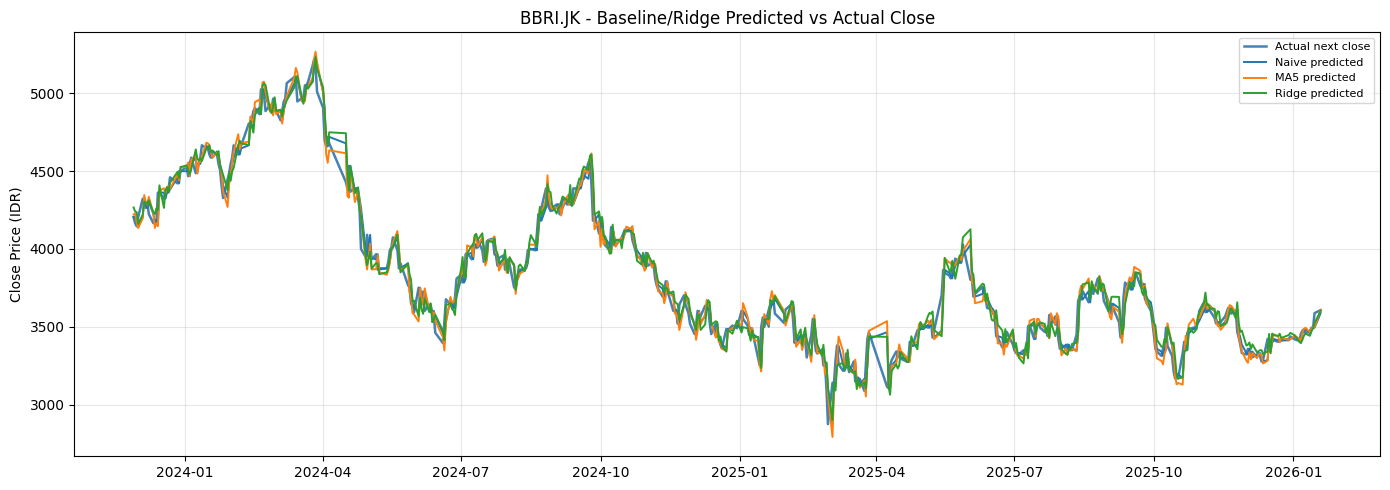

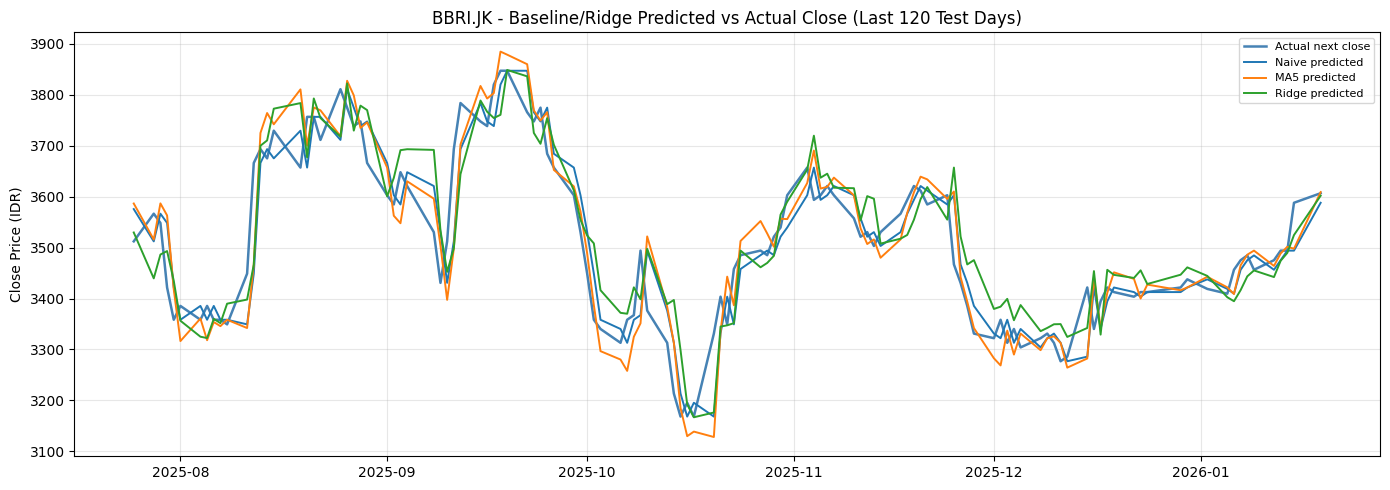

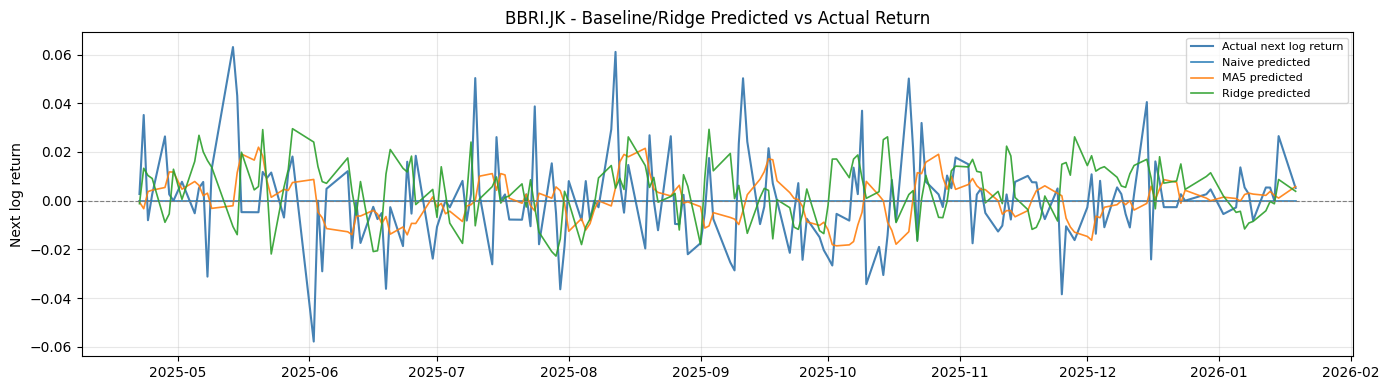

In [25]:
baseline_prediction_map = {
    'Naive': test_naive,
    'MA5': test_ma5,
    'Ridge': test_ridge_pred,
}

plot_test_predictions(
    baseline_prediction_map,
    f'{TICKER} - Baseline/Ridge Predicted vs Actual Close',
    f'return_{SAFE_TICKER}_baseline_prediction_vs_actual.png',
)

plot_test_predictions(
    baseline_prediction_map,
    f'{TICKER} - Baseline/Ridge Predicted vs Actual Close (Last 120 Test Days)',
    f'return_{SAFE_TICKER}_baseline_test_zoom.png',
    last_n=120,
)

plot_return_predictions(
    baseline_prediction_map,
    f'{TICKER} - Baseline/Ridge Predicted vs Actual Return',
    f'return_{SAFE_TICKER}_baseline_return_prediction.png',
    last_n=180,
)


## Walk-Forward Validation


In [26]:
walk_rows = []
tscv = TimeSeriesSplit(n_splits=3)
for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train), start=1):
    fold_model = Ridge(alpha=10.0)
    fold_model.fit(flatten(X_train[tr_idx]), y_train[tr_idx])
    pred_return = fold_model.predict(flatten(X_train[val_idx]))
    pred_close = close_from_returns(train_base_close[val_idx], pred_return)
    walk_rows.append({'Ticker': TICKER, 'Fold': fold, **compute_metrics(y_train[val_idx], pred_return, train_target_close[val_idx], pred_close)})
walk_forward_df = pd.DataFrame(walk_rows)
display(walk_forward_df.style.format({
    'Return_MAE': '{:.5f}', 'Return_RMSE': '{:.5f}',
    'Price_MAE': '{:,.2f}', 'Price_RMSE': '{:,.2f}', 'Price_MAPE': '{:.3f}%',
    'Price_R2': '{:.4f}', 'Direction_Accuracy': '{:.2f}%'
}))


,Ticker,Fold,Return_MAE,Return_RMSE,Price_MAE,Price_RMSE,Price_MAPE,Price_R2,Direction_Accuracy
0,BBRI.JK,1,0.02060,0.02677,43.49,57.05,2.066%,0.9665,42.38%
1,BBRI.JK,2,0.02227,0.03018,52.60,68.80,2.225%,0.9691,51.09%
2,BBRI.JK,3,0.01436,0.01857,51.76,67.55,1.434%,0.9792,46.34%


## LSTM Return Model


In [27]:
CONFIG = {'units': 32, 'dropout': 0.20, 'l2_reg': 1e-4, 'lr': 3e-4, 'batch_size': 32, 'epochs': 80, 'es_patience': 12}

def set_seed(seed):
    random.seed(seed); np.random.seed(seed); os.environ['PYTHONHASHSEED'] = str(seed)
    if tf is not None:
        tf.random.set_seed(seed)

def build_model(input_shape, units, dropout, l2_reg, lr, **_):
    if tf is None:
        raise ImportError(f'TensorFlow belum tersedia di environment ini: {TF_IMPORT_ERROR}')
    model = Sequential([
        LSTM(units, return_sequences=False, kernel_regularizer=l2(l2_reg), input_shape=input_shape),
        LayerNormalization(), Dropout(dropout),
        Dense(16, activation='relu', kernel_regularizer=l2(l2_reg)), Dense(1),
    ])
    model.compile(optimizer=Adam(lr), loss='huber', metrics=['mae'])
    return model

if tf is not None:
    build_model((WINDOW_SIZE, len(feature_cols)), **CONFIG).summary()
else:
    print(f'Skip model summary karena TensorFlow belum tersedia: {TF_IMPORT_ERROR}')


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 32)             │         6,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_4           │ (None, 32)             │            64 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,753 (26.38 KB)

 Trainable params: 6,753 (26.38 KB)

 Non-trainable params: 0 (0.00 B)

## Training


In [28]:
if tf is None:
    raise ImportError(f'TensorFlow belum tersedia di environment ini: {TF_IMPORT_ERROR}')

val_start = int(len(X_train) * (1 - VAL_SIZE))
X_tr, X_val = X_train[:val_start], X_train[val_start:]
y_tr, y_val = y_train_scaled[:val_start], y_train_scaled[val_start:]
callbacks = [
    EarlyStopping(monitor='val_loss', patience=CONFIG['es_patience'], restore_best_weights=True, start_from_epoch=8, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
]
ensemble, histories = [], []
for seed in SEEDS:
    set_seed(seed)
    model = build_model((WINDOW_SIZE, len(feature_cols)), **CONFIG)
    history = model.fit(X_tr, y_tr, validation_data=(X_val, y_val), epochs=CONFIG['epochs'], batch_size=CONFIG['batch_size'], callbacks=callbacks, shuffle=False, verbose=1)
    ensemble.append(model); histories.append(history.history)
    print(f'seed={seed} epochs={len(history.history["loss"])} best_val_loss={min(history.history["val_loss"]):.5f}')
model_path = RETURN_MODEL_DIR / f'return_lstm_{SAFE_TICKER}_best.keras'
ensemble[0].save(model_path)
print(f'Saved: {model_path}')


Epoch 1/80
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.6279 - mae: 1.0120 - val_loss: 0.3171 - val_mae: 0.6536 - learning_rate: 3.0000e-04
Epoch 2/80
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.5178 - mae: 0.8810 - val_loss: 0.2851 - val_mae: 0.6109 - learning_rate: 3.0000e-04
Epoch 3/80
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.4840 - mae: 0.8377 - val_loss: 0.2563 - val_mae: 0.5782 - learning_rate: 3.0000e-04
Epoch 4/80
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.4540 - mae: 0.7965 - val_loss: 0.2472 - val_mae: 0.5663 - learning_rate: 3.0000e-04
Epoch 5/80
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.4422 - mae: 0.7828 - val_loss: 0.2375 - val_mae: 0.5549 - learning_rate: 3.0000e-04
Epoch 6/80
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.4399 - mae: 0.7850 - val_loss: 0.2281 - val_mae: 0.5448 - learning_rate: 3.0000e-04
Epoch 7/80
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.4245 - mae: 0.7598 - val_loss: 0.2248 - val_mae: 0.5413 - learning_rate: 

## LSTM Evaluation & Acceptance Check


In [29]:
def inverse_return(scaled_pred):
    return target_scaler.inverse_transform(np.asarray(scaled_pred).reshape(-1, 1)).ravel()

train_lstm_scaled = np.mean([m.predict(X_train, verbose=0).ravel() for m in ensemble], axis=0)
test_lstm_scaled = np.mean([m.predict(X_test, verbose=0).ravel() for m in ensemble], axis=0)
train_lstm_pred = inverse_return(train_lstm_scaled)
test_lstm_pred = inverse_return(test_lstm_scaled)
metrics_df = pd.concat([metrics_df, evaluate_model('LSTM_Return_Ensemble', train_lstm_pred, test_lstm_pred)], ignore_index=True)

test_metrics = metrics_df[metrics_df.Split == 'Test'].copy()
naive_row = test_metrics[test_metrics.Model == 'Naive_Zero_Return'].iloc[0]
acceptance_df = pd.DataFrame([{
    'Ticker': TICKER, 'Model': row.Model,
    'Beats_Naive_Return_RMSE': row.Return_RMSE < naive_row.Return_RMSE,
    'Beats_Naive_Price_RMSE': row.Price_RMSE < naive_row.Price_RMSE,
    'Beats_Naive_DA': row.Direction_Accuracy > naive_row.Direction_Accuracy,
    'Naive_Return_RMSE': naive_row.Return_RMSE,
    'Model_Return_RMSE': row.Return_RMSE,
    'Naive_DA': naive_row.Direction_Accuracy,
    'Model_DA': row.Direction_Accuracy,
} for _, row in test_metrics.iterrows() if row.Model != 'Naive_Zero_Return'])

display(test_metrics.style.format({
    'Return_MAE': '{:.5f}', 'Return_RMSE': '{:.5f}',
    'Price_MAE': '{:,.2f}', 'Price_RMSE': '{:,.2f}', 'Price_MAPE': '{:.3f}%',
    'Price_R2': '{:.4f}', 'Direction_Accuracy': '{:.2f}%'
}))
display(acceptance_df)


,Ticker,Split,Model,Return_MAE,Return_RMSE,Price_MAE,Price_RMSE,Price_MAPE,Price_R2,Direction_Accuracy
1,BBRI.JK,Test,Naive_Zero_Return,0.01495,0.02042,56.37,75.75,1.496%,0.9756,6.32%
3,BBRI.JK,Test,MA5_Return,0.01649,0.02237,62.19,82.59,1.648%,0.9709,48.02%
5,BBRI.JK,Test,Ridge_Return,0.01729,0.02283,65.17,85.02,1.733%,0.9692,47.23%
7,BBRI.JK,Test,LSTM_Return_Ensemble,0.01531,0.02076,57.70,77.07,1.530%,0.9747,44.66%


,Ticker,Model,Beats_Naive_Return_RMSE,Beats_Naive_Price_RMSE,Beats_Naive_DA,Naive_Return_RMSE,Model_Return_RMSE,Naive_DA,Model_DA
0,BBRI.JK,MA5_Return,False,False,True,0.020417,0.022369,6.324111,48.023715
1,BBRI.JK,Ridge_Return,False,False,True,0.020417,0.022829,6.324111,47.233202
2,BBRI.JK,LSTM_Return_Ensemble,False,False,True,0.020417,0.020762,6.324111,44.664032


## Metrics Evaluation - Final Model
Setelah cell LSTM evaluation selesai, tabel ini menampilkan metrik final di notebook.


In [30]:
# FINAL METRIK EVALUASI DI NOTEBOOK, TERMASUK LSTM
show_metrics(f'{TICKER} - FINAL TRAIN & TEST METRICS', metrics_df)

print('\nFINAL TEST-ONLY METRICS')
display(
    metrics_df[metrics_df['Split'] == 'Test'][METRIC_COLUMNS]
    .sort_values('Return_RMSE')
    .style
    .format(METRIC_FORMAT)
    .background_gradient(subset=['Return_RMSE', 'Price_RMSE', 'Price_MAPE'], cmap='RdYlGn_r')
    .background_gradient(subset=['Price_R2', 'Direction_Accuracy'], cmap='RdYlGn')
)

print('\nFINAL ACCEPTANCE CHECK VS NAIVE BASELINE')
display(acceptance_df.style.format({
    'Naive_Return_RMSE': '{:.5f}',
    'Model_Return_RMSE': '{:.5f}',
    'Naive_DA': '{:.2f}%',
    'Model_DA': '{:.2f}%',
}))



BBRI.JK - FINAL TRAIN & TEST METRICS


,Ticker,Split,Model,Return_MAE,Return_RMSE,Price_MAE,Price_RMSE,Price_MAPE,Price_R2,Direction_Accuracy
7,BBRI.JK,Test,LSTM_Return_Ensemble,0.01531,0.02076,57.70,77.07,1.530%,0.9747,44.66%
3,BBRI.JK,Test,MA5_Return,0.01649,0.02237,62.19,82.59,1.648%,0.9709,48.02%
1,BBRI.JK,Test,Naive_Zero_Return,0.01495,0.02042,56.37,75.75,1.496%,0.9756,6.32%
5,BBRI.JK,Test,Ridge_Return,0.01729,0.02283,65.17,85.02,1.733%,0.9692,47.23%
6,BBRI.JK,Train,LSTM_Return_Ensemble,0.01367,0.01971,30.69,43.96,1.365%,0.9976,49.90%
2,BBRI.JK,Train,MA5_Return,0.01536,0.02213,34.44,48.99,1.534%,0.9970,42.18%
0,BBRI.JK,Train,Naive_Zero_Return,0.01381,0.01999,30.94,44.40,1.379%,0.9975,11.19%
4,BBRI.JK,Train,Ridge_Return,0.01183,0.01583,27.43,38.20,1.183%,0.9982,59.90%



FINAL TEST-ONLY METRICS


,Ticker,Split,Model,Return_MAE,Return_RMSE,Price_MAE,Price_RMSE,Price_MAPE,Price_R2,Direction_Accuracy
1,BBRI.JK,Test,Naive_Zero_Return,0.01495,0.02042,56.37,75.75,1.496%,0.9756,6.32%
7,BBRI.JK,Test,LSTM_Return_Ensemble,0.01531,0.02076,57.70,77.07,1.530%,0.9747,44.66%
3,BBRI.JK,Test,MA5_Return,0.01649,0.02237,62.19,82.59,1.648%,0.9709,48.02%
5,BBRI.JK,Test,Ridge_Return,0.01729,0.02283,65.17,85.02,1.733%,0.9692,47.23%



FINAL ACCEPTANCE CHECK VS NAIVE BASELINE


,Ticker,Model,Beats_Naive_Return_RMSE,Beats_Naive_Price_RMSE,Beats_Naive_DA,Naive_Return_RMSE,Model_Return_RMSE,Naive_DA,Model_DA
0,BBRI.JK,MA5_Return,False,False,True,0.02042,0.02237,6.32%,48.02%
1,BBRI.JK,Ridge_Return,False,False,True,0.02042,0.02283,6.32%,47.23%
2,BBRI.JK,LSTM_Return_Ensemble,False,False,True,0.02042,0.02076,6.32%,44.66%


## Plots


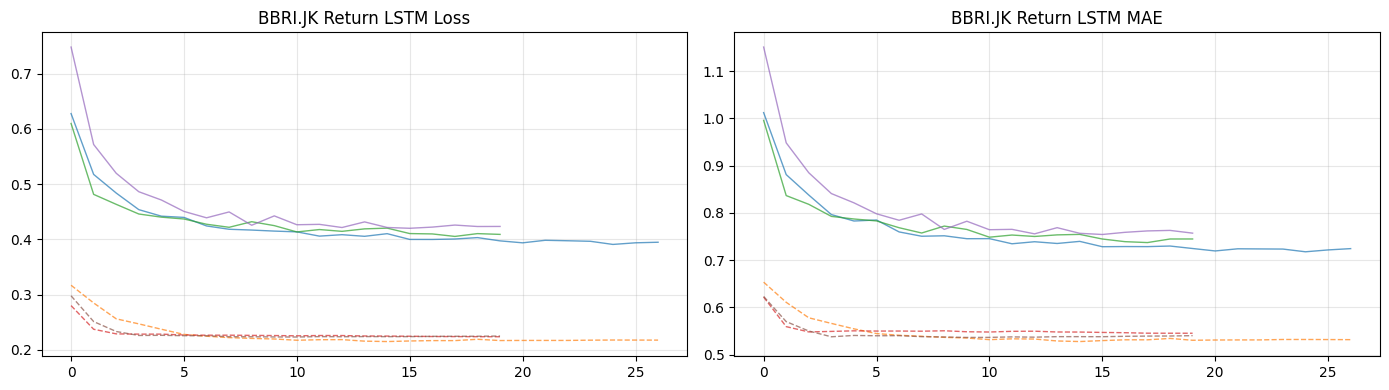

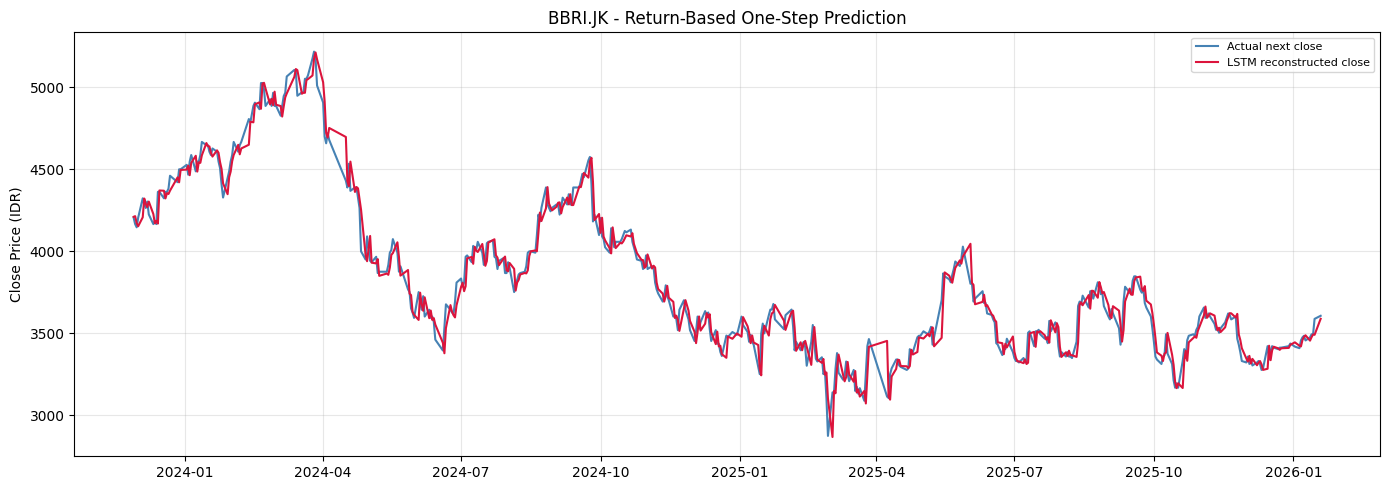

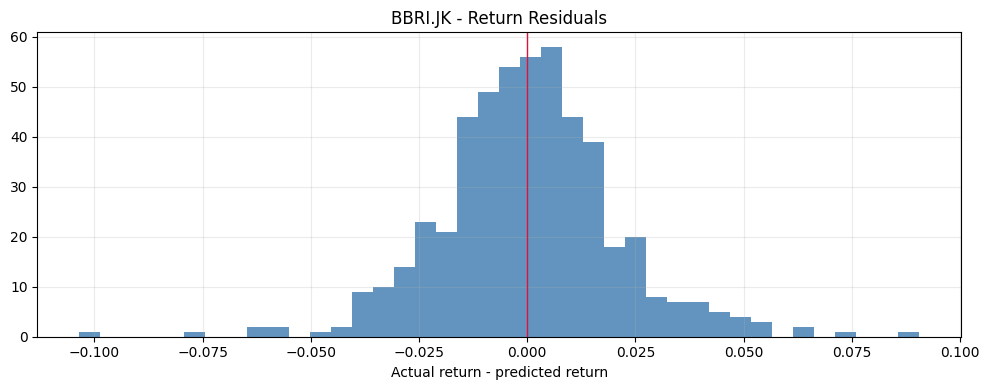

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for h in histories:
    axes[0].plot(h['loss'], alpha=0.7, lw=1); axes[0].plot(h['val_loss'], alpha=0.7, lw=1, linestyle='--')
    axes[1].plot(h['mae'], alpha=0.7, lw=1); axes[1].plot(h['val_mae'], alpha=0.7, lw=1, linestyle='--')
axes[0].set_title(f'{TICKER} Return LSTM Loss'); axes[1].set_title(f'{TICKER} Return LSTM MAE')
for ax in axes: ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(RETURN_PLOT_DIR / f'return_{SAFE_TICKER}_training_curves.png', dpi=130, bbox_inches='tight'); plt.show()

test_pred_close = close_from_returns(test_base_close, test_lstm_pred)
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_dates, test_target_close, color=ACTUAL_COLOR, lw=1.5, label='Actual next close')
ax.plot(test_dates, test_pred_close, color=LSTM_COLOR, lw=1.5, label='LSTM reconstructed close')
ax.set_title(f'{TICKER} - Return-Based One-Step Prediction'); ax.set_ylabel('Close Price (IDR)')
ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(RETURN_PLOT_DIR / f'return_{SAFE_TICKER}_prediction_vs_actual.png', dpi=130, bbox_inches='tight'); plt.show()

residuals = y_test - test_lstm_pred
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(residuals, bins=40, color=ACTUAL_COLOR, alpha=0.85); ax.axvline(0, color=LSTM_COLOR, lw=1)
ax.set_title(f'{TICKER} - Return Residuals'); ax.set_xlabel('Actual return - predicted return'); ax.grid(alpha=0.25)
plt.tight_layout(); plt.savefig(RETURN_PLOT_DIR / f'return_{SAFE_TICKER}_residuals.png', dpi=130, bbox_inches='tight'); plt.show()


## Fit Status - Overfit / Good Fit / Underfit
Label ini dihitung dari gap error train vs test. Fokus utama pakai `Return_RMSE`, dengan `Price_RMSE` sebagai sanity check.


In [ ]:
def classify_fit(metrics_table):
    rows = []
    for model_name in metrics_table['Model'].unique():
        model_metrics = metrics_table[metrics_table['Model'] == model_name]
        if set(model_metrics['Split']) < {'Train', 'Test'}:
            continue
        train = model_metrics[model_metrics['Split'] == 'Train'].iloc[0]
        test = model_metrics[model_metrics['Split'] == 'Test'].iloc[0]
        return_gap = test.Return_RMSE / max(train.Return_RMSE, 1e-12)
        price_gap = test.Price_RMSE / max(train.Price_RMSE, 1e-12)

        if return_gap <= 1.25 and price_gap <= 1.50:
            status = 'Good fit'
            reason = 'Train-test gap kecil.'
        elif return_gap <= 1.75 and price_gap <= 2.25:
            status = 'Mild overfit'
            reason = 'Test error lebih tinggi, tapi gap belum ekstrem.'
        elif return_gap > 1.75 or price_gap > 2.25:
            status = 'Overfit'
            reason = 'Train jauh lebih bagus daripada test.'
        else:
            status = 'Likely underfit'
            reason = 'Train dan test sama-sama lemah; perlu cek baseline.'

        rows.append({
            'Ticker': TICKER,
            'Model': model_name,
            'Train_Return_RMSE': train.Return_RMSE,
            'Test_Return_RMSE': test.Return_RMSE,
            'Return_Gap_Test/Train': return_gap,
            'Train_Price_RMSE': train.Price_RMSE,
            'Test_Price_RMSE': test.Price_RMSE,
            'Price_Gap_Test/Train': price_gap,
            'Fit_Status': status,
            'Reason': reason,
        })
    return pd.DataFrame(rows)

fit_status_df = classify_fit(metrics_df)
print('\nFIT STATUS / OVERFIT CHECK')
display(fit_status_df.style.format({
    'Train_Return_RMSE': '{:.5f}',
    'Test_Return_RMSE': '{:.5f}',
    'Return_Gap_Test/Train': '{:.2f}x',
    'Train_Price_RMSE': '{:,.2f}',
    'Test_Price_RMSE': '{:,.2f}',
    'Price_Gap_Test/Train': '{:.2f}x',
}))


## Prediction Visualization - Final LSTM
Visualisasi final predicted vs actual setelah LSTM selesai training.


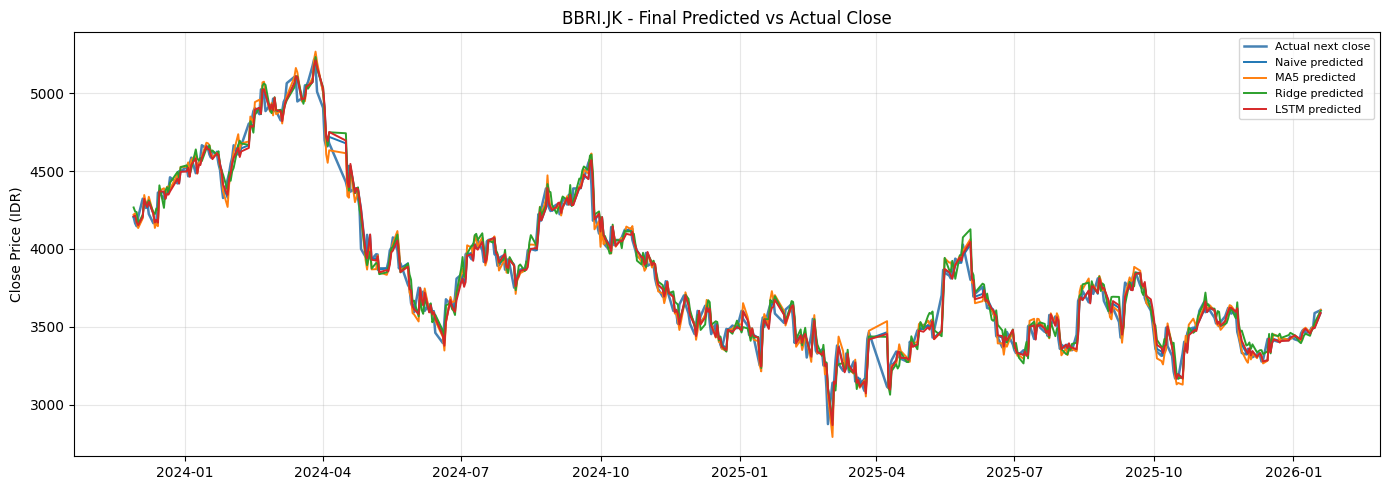

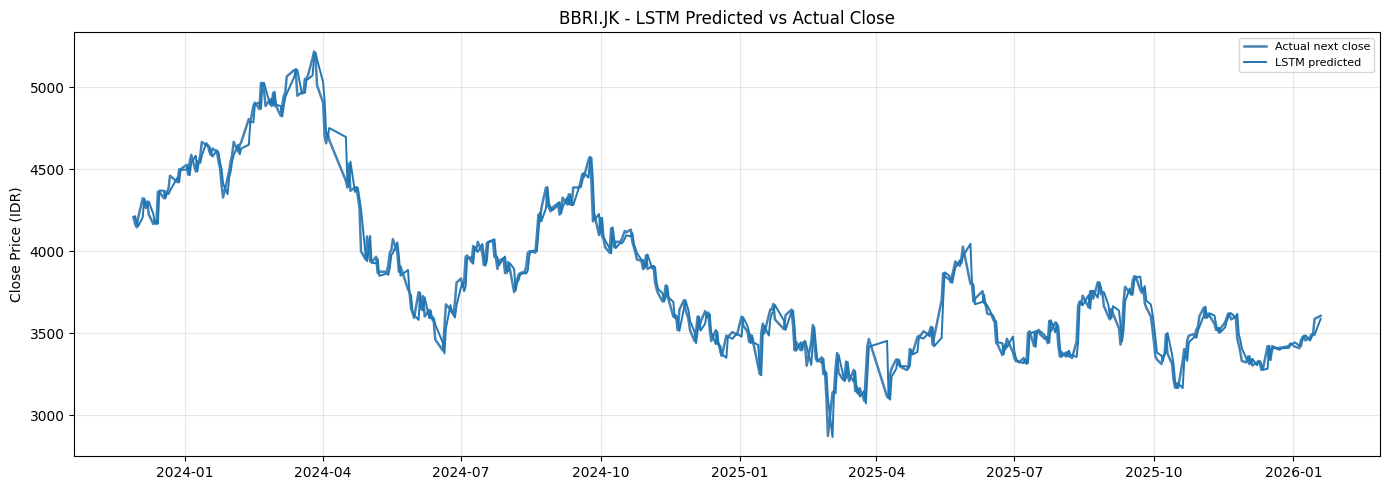

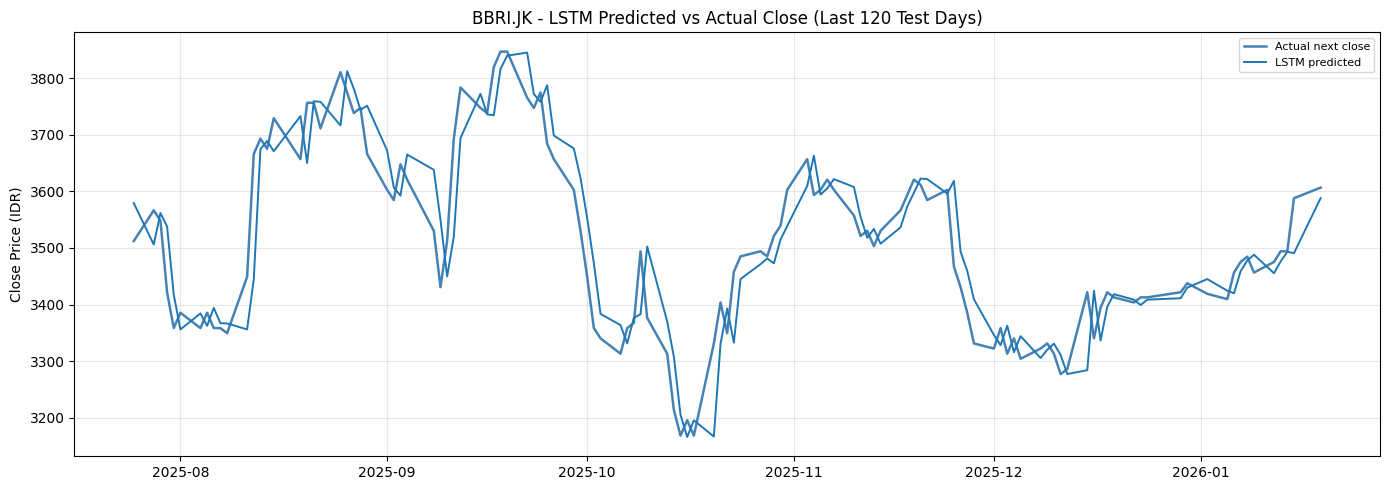

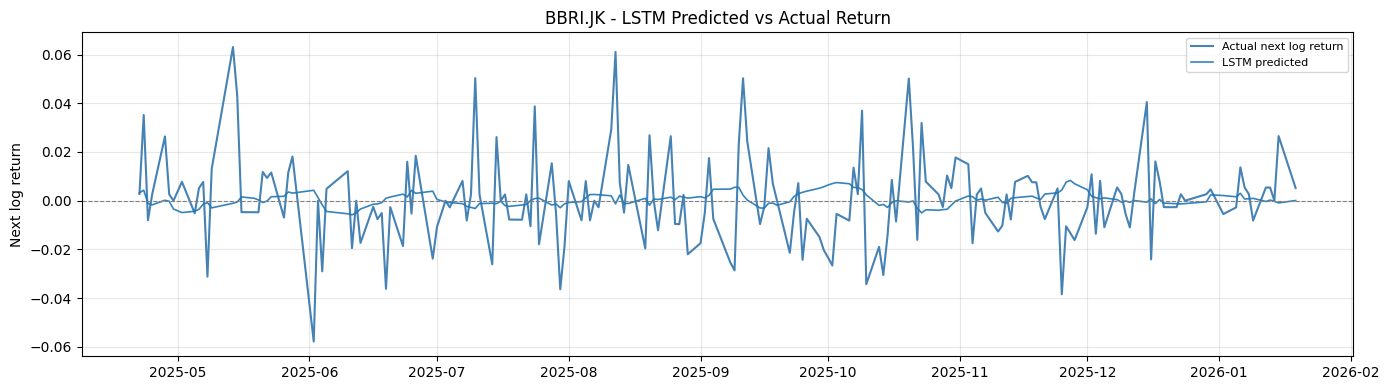

In [32]:
final_prediction_map = {
    'Naive': test_naive,
    'MA5': test_ma5,
    'Ridge': test_ridge_pred,
    'LSTM': test_lstm_pred,
}

plot_test_predictions(
    final_prediction_map,
    f'{TICKER} - Final Predicted vs Actual Close',
    f'return_{SAFE_TICKER}_final_prediction_vs_actual.png',
)

plot_test_predictions(
    {'LSTM': test_lstm_pred},
    f'{TICKER} - LSTM Predicted vs Actual Close',
    f'return_{SAFE_TICKER}_lstm_prediction_vs_actual.png',
)

plot_test_predictions(
    {'LSTM': test_lstm_pred},
    f'{TICKER} - LSTM Predicted vs Actual Close (Last 120 Test Days)',
    f'return_{SAFE_TICKER}_lstm_test_zoom.png',
    last_n=120,
)

plot_return_predictions(
    {'LSTM': test_lstm_pred},
    f'{TICKER} - LSTM Predicted vs Actual Return',
    f'return_{SAFE_TICKER}_lstm_return_prediction.png',
    last_n=180,
)


## 30-Day Price Forecast
Visualisasi forecast 30 hari ke depan. Ini scenario forecast berbasis prediksi return rekursif, jadi gunakan sebagai insight arah/skenario, bukan kepastian harga.


In [ ]:
FORECAST_DAYS = 30

# Forecast scenario: recursive one-step return prediction.
# Price/return/volatility features are updated from simulated closes.
# Non-price features that require unknown future data, such as volume/RSI/MACD, are carried forward.
def recursive_return_forecast(models, last_feature_window_raw, last_close, forecast_days=30):
    raw_window = last_feature_window_raw.copy()
    close_history = list(df['Close'].iloc[-80:].astype(float).values)
    pred_returns = []
    pred_closes = []
    current_close = float(last_close)

    for _ in range(forecast_days):
        scaled_window = feature_scaler.transform(raw_window).reshape(1, WINDOW_SIZE, len(feature_cols)).astype(np.float32)
        scaled_pred = np.mean([m.predict(scaled_window, verbose=0).ravel()[0] for m in models])
        pred_return = float(inverse_return([scaled_pred])[0])
        current_close = float(current_close * np.exp(pred_return))
        pred_returns.append(pred_return)
        pred_closes.append(current_close)

        close_history.append(current_close)
        returns = pd.Series(np.log(pd.Series(close_history) / pd.Series(close_history).shift(1))).dropna()
        prices = pd.Series(close_history)

        new_row = raw_window[-1].copy()
        feature_idx = {name: i for i, name in enumerate(feature_cols)}
        updates = {
            'Close_Log_Return_1': pred_return,
            'Daily_Return': np.exp(pred_return) - 1,
            'Return_3': prices.pct_change(3).iloc[-1],
            'Return_5': prices.pct_change(5).iloc[-1],
            'Return_10': prices.pct_change(10).iloc[-1],
            'Volatility_5': returns.rolling(5).std().iloc[-1],
            'Volatility_10': returns.rolling(10).std().iloc[-1],
            'Volatility_20': returns.rolling(20).std().iloc[-1],
        }
        for name, value in updates.items():
            if name in feature_idx and np.isfinite(value):
                new_row[feature_idx[name]] = value
        raw_window = np.vstack([raw_window[1:], new_row])

    future_dates = pd.bdate_range(start=pd.Timestamp(df['Date'].iloc[-1]) + pd.Timedelta(days=1), periods=forecast_days)
    return pd.DataFrame({
        'Date': future_dates,
        'Predicted_Log_Return': pred_returns,
        'Predicted_Close': pred_closes,
    })

forecast_30d = recursive_return_forecast(
    ensemble,
    X_raw[-1],
    df['Close'].iloc[-1],
    forecast_days=FORECAST_DAYS,
)

display(forecast_30d.head())
display(forecast_30d.tail())

last_n = 90
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['Date'].iloc[-last_n:], df['Close'].iloc[-last_n:], color=ACTUAL_COLOR, lw=1.8, label='Historical actual close')
ax.plot(forecast_30d['Date'], forecast_30d['Predicted_Close'], color=LSTM_COLOR, lw=2.2, linestyle='--', label='30-day forecast')
ax.axvline(df['Date'].iloc[-1], color=NAIVE_COLOR, lw=1, linestyle=':', label='Forecast start')
ax.fill_between(
    forecast_30d['Date'],
    forecast_30d['Predicted_Close'] * 0.97,
    forecast_30d['Predicted_Close'] * 1.03,
    color=LSTM_COLOR,
    alpha=0.10,
    label='?3% visual band',
)
ax.set_title(f'{TICKER} - 30-Day Price Forecast')
ax.set_ylabel('Close Price (IDR)')
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(RETURN_PLOT_DIR / f'return_{SAFE_TICKER}_forecast_30d.png', dpi=130, bbox_inches='tight')
plt.show()

forecast_path = RETURN_REPORT_DIR / f'return_{SAFE_TICKER}_forecast_30d.csv'
forecast_30d.to_csv(forecast_path, index=False)
print('Saved:', forecast_path)


## Key Drivers


,Feature,Ridge_Abs_Coefficient
12,BB_width_pct,0.002408
6,Volatility_10,0.002257
2,Return_3,0.002121
4,Return_10,0.001973
11,MACD_Hist,0.001941
7,Volatility_20,0.001894
5,Volatility_5,0.001634
3,Return_5,0.001584
8,RSI,0.001358
0,Close_Log_Return_1,0.001175


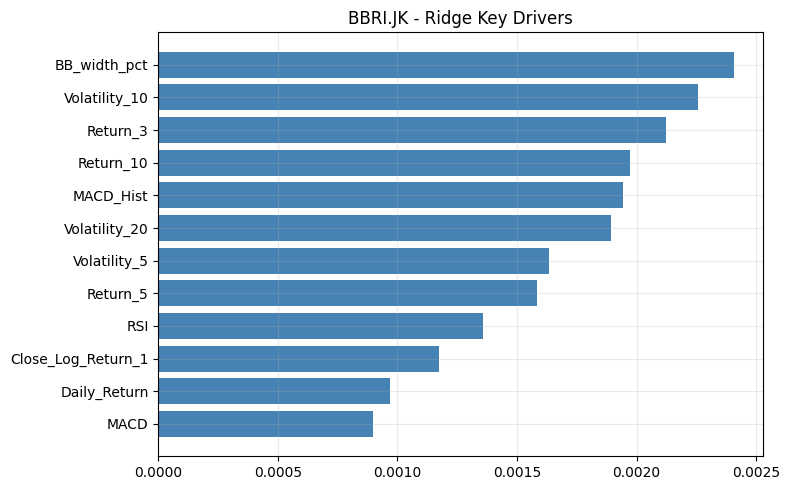

In [33]:
coef = ridge.coef_.reshape(WINDOW_SIZE, len(feature_cols))
ridge_importance = pd.DataFrame({'Feature': feature_cols, 'Ridge_Abs_Coefficient': np.abs(coef).mean(axis=0)}).sort_values('Ridge_Abs_Coefficient', ascending=False)
display(ridge_importance.style.format({'Ridge_Abs_Coefficient': '{:.6f}'}))

fig, ax = plt.subplots(figsize=(8, 5))
plot_df = ridge_importance.sort_values('Ridge_Abs_Coefficient').tail(12)
ax.barh(plot_df['Feature'], plot_df['Ridge_Abs_Coefficient'], color=ACTUAL_COLOR)
ax.set_title(f'{TICKER} - Ridge Key Drivers'); ax.grid(alpha=0.25)
plt.tight_layout(); plt.savefig(RETURN_PLOT_DIR / f'return_{SAFE_TICKER}_ridge_key_drivers.png', dpi=130, bbox_inches='tight'); plt.show()


## Optional LSTM Permutation Importance


,Feature,MSE_Increase
8,RSI,0.00000884
10,MACD_signal,0.00000641
2,Return_3,0.00000338
4,Return_10,0.00000312
11,MACD_Hist,0.00000261
12,BB_width_pct,0.00000144
9,MACD,0.00000111
3,Return_5,0.00000009
6,Volatility_10,0.00000002
14,Volume_Ratio_7,-0.00000011


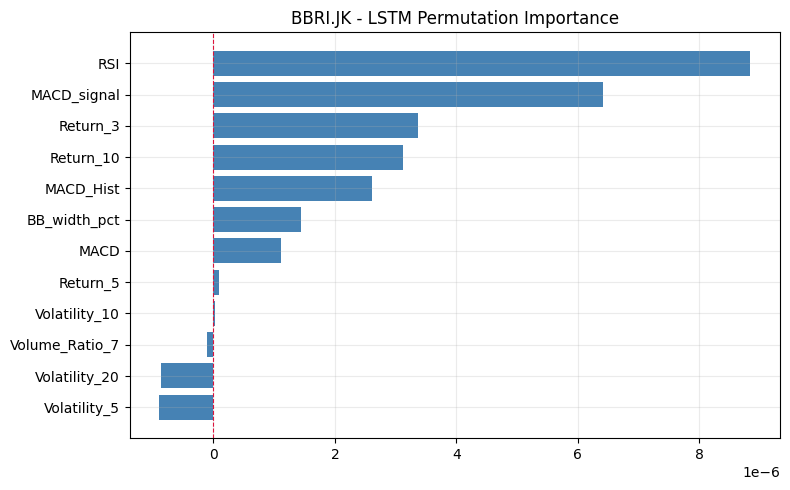

In [34]:
base_pred = test_lstm_pred
base_mse = mean_squared_error(y_test, base_pred)
rng = np.random.RandomState(42)
imp_rows = []
for i, col in enumerate(feature_cols):
    X_perm = X_test.copy()
    flat = X_perm[:, :, i].flatten(); rng.shuffle(flat)
    X_perm[:, :, i] = flat.reshape(X_perm.shape[0], X_perm.shape[1])
    perm_scaled = np.mean([m.predict(X_perm, verbose=0).ravel() for m in ensemble], axis=0)
    perm_pred = inverse_return(perm_scaled)
    imp_rows.append({'Feature': col, 'MSE_Increase': mean_squared_error(y_test, perm_pred) - base_mse})

lstm_importance = pd.DataFrame(imp_rows).sort_values('MSE_Increase', ascending=False)
display(lstm_importance.style.format({'MSE_Increase': '{:.8f}'}))
fig, ax = plt.subplots(figsize=(8, 5))
plot_df = lstm_importance.sort_values('MSE_Increase').tail(12)
ax.barh(plot_df['Feature'], plot_df['MSE_Increase'], color=ACTUAL_COLOR); ax.axvline(0, color=LSTM_COLOR, lw=0.8, linestyle='--')
ax.set_title(f'{TICKER} - LSTM Permutation Importance'); ax.grid(alpha=0.25)
plt.tight_layout(); plt.savefig(RETURN_PLOT_DIR / f'return_{SAFE_TICKER}_lstm_feature_importance.png', dpi=130, bbox_inches='tight'); plt.show()


## One-Step Signal & Save Reports
Recursive 30-day forecast sengaja tidak dibuat karena rolling indicator masa depan akan stale jika hanya `Close` yang di-update.


In [35]:
one_step_signal = pd.DataFrame([{
    'Ticker': TICKER,
    'Signal_Date': pd.Timestamp(test_dates.iloc[-1]).date().isoformat(),
    'Base_Close': float(test_base_close[-1]),
    'Predicted_Next_Log_Return': float(test_lstm_pred[-1]),
    'Predicted_Next_Close': float(test_base_close[-1] * np.exp(test_lstm_pred[-1])),
    'Note': 'One-step signal only; recursive 30-day forecast intentionally disabled.',
}])
display(one_step_signal)

outputs = {
    f'return_{SAFE_TICKER}_metrics.csv': metrics_df,
    f'return_{SAFE_TICKER}_diagnostics.csv': diagnostics_df,
    f'return_{SAFE_TICKER}_walk_forward.csv': walk_forward_df,
    f'return_{SAFE_TICKER}_acceptance.csv': acceptance_df,
    f'return_{SAFE_TICKER}_one_step_signal.csv': one_step_signal,
    f'return_{SAFE_TICKER}_fit_status.csv': fit_status_df,
}
for name, table in outputs.items():
    path = RETURN_REPORT_DIR / name
    table.to_csv(path, index=False)
    print('Saved:', path)


,Ticker,Signal_Date,Base_Close,Predicted_Next_Log_Return,Predicted_Next_Close,Note
0,BBRI.JK,2026-01-19,3587.912842,0.00008,3588.201172,One-step signal only; recursive 30-day forecas...


Saved: c:\Users\akbar\VSCode Project\RaksaDana\reports\return_BBRI_JK_metrics.csv
Saved: c:\Users\akbar\VSCode Project\RaksaDana\reports\return_BBRI_JK_diagnostics.csv
Saved: c:\Users\akbar\VSCode Project\RaksaDana\reports\return_BBRI_JK_walk_forward.csv
Saved: c:\Users\akbar\VSCode Project\RaksaDana\reports\return_BBRI_JK_acceptance.csv
Saved: c:\Users\akbar\VSCode Project\RaksaDana\reports\return_BBRI_JK_one_step_signal.csv
